# Phase 7 : modélisation

Projet final Machine Learning, blocs 6 et 8.

## Ce que ce notebook est

Une **adaptation** du squelette fourni par le formateur,
`reference/Ressource_Workflow_ML_Complet.ipynb`, et non une réécriture. Le squelette marque trois
zones à modifier, `# <-- A ADAPTER` : les données, la cible, et la grille d'hyperparamètres.
Elles sont reprises telles quelles et signalées dans le code.

Deux écarts au squelette sont assumés et justifiés en section 3. Ils ont été décidés en phase 0
et ne sont pas des improvisations.

| Squelette | Ce projet | Pourquoi |
|---|---|---|
| `train_test_split` aléatoire | Split chronologique sur la date | Le modèle sert à prédire des parties futures |
| `cv=5`, donc `KFold` | `TimeSeriesSplit(n_splits=5)` | Un `KFold` remélange l'ordre temporel à l'intérieur du train |

## Cadrage du problème de ML

Le template de la section 1 du guide, rempli.

| Élément | Valeur |
|---|---|
| Question prédictive | Peut-on prédire, à la 15e minute, quelle équipe gagne une partie professionnelle ? |
| Colonne cible | `result`, 1 si l'équipe gagne |
| Type de problème | Classification binaire, classes équilibrées à 50,0 % |
| Features | Les 23 colonnes des allow-lists de `src/config.py`, toutes connues à la 15e minute |
| Exclusions | Tout ce que liste `config.LEAKY_COLUMNS`, plus `league`, `year`, `patch_major`, `split` et `teamname` qui ne survivent pas à la frontière 2025 / 2026 |
| Métrique principale | ROC AUC |
| Métriques secondaires | Accuracy pour la communication, log loss pour la calibration |
| Baseline à battre | « L'équipe la plus riche à la 15e minute gagne », mesurée en section 4 |

**Pourquoi l'AUC et pas l'accuracy.** Les classes sont parfaitement équilibrées, donc l'accuracy
n'est pas trompeuse ici, mais le livrable métier est une **probabilité affichée à l'écran**, pas
un verdict. L'AUC juge le classement des probabilités et la log loss juge leur calibration. Un
modèle qui annonce 95 % et se trompe une fois sur trois est inutilisable pour une plateforme de
statistiques, quelle que soit son accuracy.

## Les trois règles éliminatoires, et où elles sont traitées

1. **Fuite de données.** Aucun preprocessing hors `Pipeline`, aucune colonne postérieure à la
   15e minute, features historiques en fenêtre passée seule. Contrôlé en section 2.
2. **Notebook exécutable de bout en bout.** `random_state` fixé partout, aucun état caché.
3. **Baselines.** Les trois sont calculées en section 4, **avant** le premier modèle.

## Livrables

`models/pipeline_final.joblib`, quatre figures `07_*` et `docs/rapport_modelisation.md`.

Données fournies par Oracle's Elixir (Tim Sevenhuysen, oracleselixir.com).

## 1. Importations et chargement

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, log_loss,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import config, viz

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

viz.appliquer_style()
PALETTE = viz.PALETTE
fr, nb = viz.entier_fr, viz.nombre_fr

# Le squelette fixe RANDOM_STATE une seule fois puis le passe partout. Ici on le prend
# dans config, comme ca tous les notebooks utilisent la meme valeur.
RANDOM_STATE = config.RANDOM_STATE

donnees = pd.read_parquet(config.DATA_PROCESSED / "lol_at15.parquet")  # <-- A ADAPTER
CIBLE = config.TARGET                                                  # <-- A ADAPTER

print(f"Dataset : {fr(len(donnees))} lignes x {donnees.shape[1]} colonnes")
print(f"Cible   : {CIBLE}, equilibree a {100 * donnees[CIBLE].mean():.2f} %")
print(f"Graine  : {RANDOM_STATE}")

Dataset : 92 616 lignes x 49 colonnes
Cible   : result, equilibree a 50.00 %
Graine  : 42


## 2. Contrôle anti-fuite avant toute modélisation

La checklist de la section 2 du guide, exécutée plutôt que cochée. Chaque ligne échoue bruyamment
si elle est fausse.

In [2]:
FEATURES = (config.NUMERIC_FEATURES + config.CATEGORICAL_FEATURES
            + config.BOOLEAN_FEATURES)

controles = [
    ("Aucune colonne de la deny-list dans les features",
     not set(FEATURES) & set(config.LEAKY_COLUMNS)),
    ("Aucune colonne de fuite meme presente dans le dataset",
     not set(donnees.columns) & set(config.LEAKY_COLUMNS)),
    ("Aucun identifiant dans les features",
     not set(FEATURES) & {"gameid", "teamid", "team_key", "teamname", "roster_key"}),
    ("Aucune categorielle bornee dans le temps",
     not set(FEATURES) & {"year", "league", "patch_major", "patch", "split", "saison"}),
    ("Toutes les features sont presentes dans le dataset",
     all(f in donnees.columns for f in FEATURES)),
    ("La cible n'est pas dans les features", CIBLE not in FEATURES),
]

bilan = pd.DataFrame(controles, columns=["controle", "ok"])
bilan["statut"] = bilan["ok"].map({True: "ok", False: "ECHEC"})
print(bilan[["controle", "statut"]].to_string(index=False))
assert bilan["ok"].all(), "Controle anti-fuite en echec"
print()
print(f"{len(FEATURES)} features retenues :")
print(f"  numeriques    ({len(config.NUMERIC_FEATURES)})")
print(f"  categorielles ({len(config.CATEGORICAL_FEATURES)}) : {config.CATEGORICAL_FEATURES}")
print(f"  booleennes    ({len(config.BOOLEAN_FEATURES)}) : {config.BOOLEAN_FEATURES}")

                                             controle statut
     Aucune colonne de la deny-list dans les features     ok
Aucune colonne de fuite meme presente dans le dataset     ok
                  Aucun identifiant dans les features     ok
             Aucune categorielle bornee dans le temps     ok
   Toutes les features sont presentes dans le dataset     ok
                 La cible n'est pas dans les features     ok

23 features retenues :
  numeriques    (16)
  categorielles (3) : ['side', 'region', 'tier_ligue']
  booleennes    (4) : ['playoffs', 'firstblood', 'firstdragon', 'firstherald']


Un mot sur le troisième contrôle. Les identifiants sont exclus non pas parce qu'ils fuiteraient
le résultat, mais parce qu'ils ne portent rien de généralisable : un `gameid` vu à
l'entraînement ne réapparaîtra jamais. `teamname` est le cas limite, il porte une vraie
information, le niveau de l'équipe. Il reste exclu parce que les rosters changent chaque année
et que l'encoder produirait des centaines de modalités absentes de 2026.

## 3. Séparer X et y, puis le split chronologique

### Premier écart au squelette

Le squelette découpe en 60 / 20 / 20 avec `train_test_split(..., stratify=y)`. Ce projet découpe
sur la **date** : entraînement sur 2022 à 2025, test sur 2026.

Un split aléatoire mélangerait les patchs et les rosters de part et d'autre de la frontière. Le
modèle s'entraînerait sur des parties postérieures à celles qu'il évalue, ce qui est exactement
la situation qu'il ne rencontrera jamais en production. Le score serait optimiste, et l'optimisme
ne se verrait nulle part.

La coupure porte sur `date` et non sur `year`. La phase 2 a établi que `year` est une étiquette
de saison et non une année civile : 2 712 lignes se jouent entre septembre et décembre et portent
l'étiquette de la saison suivante. Couper sur l'étiquette enverrait des parties de décembre 2025
dans le test pendant que des parties postérieures resteraient à l'entraînement, ce qui casserait
l'ordre chronologique que le split existe précisément pour garantir.

### Où est passé le jeu de validation

Le squelette en isole un troisième. Ici, le rôle de validation est tenu par les cinq plis de
`TimeSeriesSplit` à l'intérieur de `GridSearchCV`, section 6. Chaque pli valide sur des parties
postérieures à celles de son entraînement, ce qui reproduit la condition réelle cinq fois au lieu
d'une. Le diagnostic de surapprentissage de la section 8 s'appuie sur l'écart entre le score
d'entraînement et le score de validation de ces plis.

In [3]:
# Il faut trier avant TimeSeriesSplit, sinon les plis ne sont pas temporels du tout.
donnees = donnees.sort_values(["date", "gameid", "side"]).reset_index(drop=True)

X = donnees[FEATURES].copy()
y = donnees[CIBLE]

# Simple conversion de types, rien d'appris : aucune statistique calculee, donc aucun
# risque de fuite. (sklearn ne gere pas les Int64 nullables de pandas.)
colonnes_num = config.NUMERIC_FEATURES
colonnes_bool = config.BOOLEAN_FEATURES
colonnes_cat = config.CATEGORICAL_FEATURES

X[colonnes_num + colonnes_bool] = X[colonnes_num + colonnes_bool].astype("float64")
X[colonnes_cat] = X[colonnes_cat].astype("str")

# Et voila le split chronologique.
est_train = donnees["date"] < config.SPLIT_DATE
X_train, y_train = X[est_train], y[est_train]
X_test, y_test = X[~est_train], y[~est_train]
dates_train = donnees.loc[est_train, "date"]

assert dates_train.is_monotonic_increasing, "Train non trie : TimeSeriesSplit serait invalide"
assert dates_train.max() < donnees.loc[~est_train, "date"].min(), "Chevauchement train / test"

print(f"Entrainement : {fr(len(X_train))} lignes, "
      f"{dates_train.min():%Y-%m-%d} au {dates_train.max():%Y-%m-%d}")
print(f"Test         : {fr(len(X_test))} lignes, "
      f"{donnees.loc[~est_train, 'date'].min():%Y-%m-%d} au "
      f"{donnees.loc[~est_train, 'date'].max():%Y-%m-%d}")
print()
print(f"Cible train : {100 * y_train.mean():.2f} %   |   "
      f"cible test : {100 * y_test.mean():.2f} %")

Entrainement : 76 070 lignes, 2022-01-10 au 2025-12-29
Test         : 16 546 lignes, 2026-01-08 au 2026-09-06

Cible train : 50.00 %   |   cible test : 50.00 %


## 4. Les trois baselines, avant tout modèle

Règle éliminatoire numéro trois : sans baseline calculée, la phase est plafonnée à 15 sur 25.
Elles sont donc ici, avant la première pipeline, et pas en commentaire.

| Baseline | Règle | Ce qu'elle mesure |
|---|---|---|
| Naïve | Toujours la classe majoritaire, via `DummyClassifier` | Le plancher absolu |
| Métier 1 | L'équipe du côté bleu gagne | La valeur du seul avantage de position |
| Métier 2 | L'équipe la plus riche à la 15e minute gagne | **La vraie référence** |

C'est la troisième qui compte. Un modèle qui ne bat pas nettement « le plus riche à 15 gagne »
n'apporte rien qu'un analyste ne sache déjà faire de tête.

In [4]:
def evaluer(nom, y_vrai, y_pred, y_proba=None):
    """Accuracy, AUC et log loss d'un jeu de predictions, dans un format commun."""
    ligne = {"modele": nom, "accuracy": accuracy_score(y_vrai, y_pred)}
    if y_proba is not None:
        ligne["roc_auc"] = roc_auc_score(y_vrai, y_proba)
        ligne["log_loss"] = log_loss(y_vrai, y_proba)
    else:
        ligne["roc_auc"] = np.nan
        ligne["log_loss"] = np.nan
    return ligne


# Baseline 1 : la classe majoritaire, comme dans le guide.
naive = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
naive.fit(X_train, y_train)

# Baselines 2 et 3 : ce sont des regles metier, rien a entrainer. `side` est passe en
# texte plus haut, d'ou la comparaison avec une chaine.
pred_bleu = (X_train["side"] == "Blue").astype(int)
pred_or = (X_train["golddiffat15"] > 0).astype(int)

baselines = pd.DataFrame([
    # Pour la baseline naive, on prend comme probabilite la proportion de positifs du
    # train, pas le 0/1 sec de DummyClassifier : une proba de 0 sur une ligne positive
    # fait partir la log loss a l'infini, et le chiffre ne voudrait plus rien dire.
    evaluer("Naive, classe majoritaire", y_train, naive.predict(X_train),
            np.full(len(y_train), y_train.mean())),
    evaluer("Metier 1, le cote bleu gagne", y_train, pred_bleu),
    evaluer("Metier 2, le plus riche a 15 gagne", y_train, pred_or),
])

print("Baselines, mesurees sur le jeu d'entrainement 2022-2025")
print(baselines.round(4).to_string(index=False))

BASELINE_A_BATTRE = baselines.loc[2, "accuracy"]
print()
print(f"Reference a battre : {100 * BASELINE_A_BATTRE:.2f} % d'accuracy")

Baselines, mesurees sur le jeu d'entrainement 2022-2025


                            modele  accuracy  roc_auc  log_loss
         Naive, classe majoritaire    0.5000      0.5    0.6931
      Metier 1, le cote bleu gagne    0.5293      NaN       NaN
Metier 2, le plus riche a 15 gagne    0.7387      NaN       NaN

Reference a battre : 73.87 % d'accuracy


La baseline naïve est à 50,0 % et 0,50 d'AUC, exactement comme la construction du dataset le
prévoit : chaque partie produit une ligne gagnante et une ligne perdante.

La baseline du côté bleu atteint 52,9 %, ce qui redit sous une autre forme le résultat de la
question business 2.

**La baseline économique atteint 73,9 %.** C'est très haut, et c'est la difficulté de ce projet :
une règle d'une ligne capture déjà l'essentiel du signal. La phase 6 l'avait annoncé, 28 % des
lignes présentent plus de 3 000 or d'écart et se prédisent presque seules. Tout le travail du
modèle se joue sur les parties serrées, et le gain attendu est donc modeste par construction.

## 5. Le preprocessing et la pipeline

Repris du squelette, étapes 4 et 5, avec une branche de plus. Le squelette en prévoit deux,
numérique et catégorielle. Ici les booléens forment une troisième branche : ce sont des 0/1 qui
n'ont pas besoin d'être centrés-réduits, et les standardiser rendrait les coefficients de la
régression logistique moins lisibles sans rien changer à la performance.

Tout le preprocessing vit **dans** la pipeline. C'est la deuxième fuite classique du guide, et la
seule protection est structurelle : un `SimpleImputer` ajusté à la main sur le dataset complet
calculerait ses médianes sur 2026 avant même le split.

In [5]:
preprocesseur = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), colonnes_num),
    ("bool", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]), colonnes_bool),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), colonnes_cat),
])

pipeline = Pipeline([
    ("preprocessing", preprocesseur),
    # Valeur provisoire : la grille de la section 6 la remplacera par chaque candidat.
    ("modele", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

# On verifie que tout est bien branche, sur le train seul, avant d'entrainer quoi que ce
# soit.
apercu = preprocesseur.fit(X_train).transform(X_train.head(3))
noms_sortie = preprocesseur.get_feature_names_out()
print(f"{X_train.shape[1]} colonnes en entree -> {apercu.shape[1]} en sortie")
print(f"dont {len(noms_sortie) - len(colonnes_num) - len(colonnes_bool)} issues du "
      f"OneHotEncoder sur {colonnes_cat}")
print()
print("Valeurs manquantes restantes apres preprocessing :", int(np.isnan(apercu).sum()))

23 colonnes en entree -> 34 en sortie
dont 14 issues du OneHotEncoder sur ['side', 'region', 'tier_ligue']

Valeurs manquantes restantes apres preprocessing : 0


`handle_unknown="ignore"` est indispensable ici. Si une modalité de `region` ou de `tier_ligue`
apparaissait en 2026 sans avoir jamais été vue, l'encodeur produirait une ligne de zéros au lieu
de lever une erreur. C'est une perte d'information silencieuse, mais c'est préférable à un
plantage en production, et la phase 0 a déjà écarté les catégorielles les plus instables pour que
le cas reste rare.

## 6. La grille et l'entraînement

### Zone `# <-- A ADAPTER` numéro trois

Trois familles de modèles, dont un modèle simple et interprétable comme le guide l'exige.

| Modèle | Rôle |
|---|---|
| `LogisticRegression` | Le modèle simple. Linéaire, coefficients lisibles, généralement le mieux calibré |
| `RandomForestClassifier` | Capture les interactions sans qu'on les déclare |
| `HistGradientBoostingClassifier` | Préféré à XGBoost : il est dans scikit-learn, gère les NaN nativement, aucune dépendance de plus |

### Second écart au squelette

Le squelette écrit `cv=5`, ce qui instancie un `KFold`. Un `KFold` mélange l'ordre chronologique
**à l'intérieur** du jeu d'entraînement, et reproduit à petite échelle le problème que le split
chronologique vient de corriger : le modèle validerait sur des parties antérieures à certaines de
ses parties d'entraînement.

`TimeSeriesSplit(n_splits=5)` entraîne sur un préfixe temporel et valide sur la tranche suivante,
cinq fois. Le prix à payer est que le premier pli n'entraîne que sur un sixième des données, donc
les scores de validation croisée sont légèrement pessimistes. C'est le bon sens de l'erreur.

Une subtilité propre à ce dataset : une ligne est une équipe, donc une partie occupe deux lignes
consécutives après le tri. Une frontière de pli peut tomber entre les deux, ce qui met une moitié
de partie de chaque côté. Avec cinq plis, cela concerne au plus quatre parties sur 38 035.

`scoring` reçoit les trois métriques du cadrage, et `refit="roc_auc"` désigne celle qui tranche.

In [6]:
param_grid = [                                                          # <-- A ADAPTER
    {"modele": [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)],
     "modele__C": [0.05, 0.5, 5.0]},
    {"modele": [RandomForestClassifier(random_state=RANDOM_STATE,
                                       n_estimators=200, n_jobs=1)],
     "modele__max_depth": [10, 20, None],
     "modele__min_samples_leaf": [5]},
    {"modele": [HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=200)],
     "modele__learning_rate": [0.05, 0.1]},
]

validation_temporelle = TimeSeriesSplit(n_splits=5)

grille = GridSearchCV(
    pipeline,
    param_grid,
    cv=validation_temporelle,
    scoring={"roc_auc": "roc_auc", "accuracy": "accuracy", "neg_log_loss": "neg_log_loss"},
    refit="roc_auc",
    return_train_score=True,
    n_jobs=-1,
)

print("Entrainement en cours, quelques minutes...")
grille.fit(X_train, y_train)

meilleur_modele = grille.best_estimator_
n_candidats = len(grille.cv_results_["params"])
print()
print(f"{n_candidats} configurations x 5 plis = {5 * n_candidats} entrainements")
print(f"Meilleur modele : {meilleur_modele.named_steps['modele'].__class__.__name__}")
print(f"AUC en validation croisee : {grille.best_score_:.4f}")
hyper = {k.replace("modele__", ""): v
         for k, v in grille.best_params_.items() if k != "modele"}
print(f"Hyperparametres : {hyper}")

Entrainement en cours, quelques minutes...



8 configurations x 5 plis = 40 entrainements
Meilleur modele : LogisticRegression
AUC en validation croisee : 0.8362
Hyperparametres : {'C': 0.05}


## 7. Le tableau de comparaison

C'est lui qui **justifie** le choix, comme le demande la checklist du guide. Sans ce tableau, le
modèle retenu est une préférence ; avec lui, c'est une décision.

In [7]:
resultats = pd.DataFrame(grille.cv_results_)
resultats["famille"] = [p["modele"].__class__.__name__ for p in resultats["params"]]
resultats["hyperparametres"] = [
    str({k.replace("modele__", ""): v for k, v in p.items() if k != "modele"})
    for p in resultats["params"]
]

colonnes = ["famille", "hyperparametres", "mean_test_roc_auc", "std_test_roc_auc",
            "mean_test_accuracy", "mean_test_neg_log_loss", "mean_train_roc_auc"]
comparaison = (resultats[colonnes]
               .sort_values("mean_test_roc_auc", ascending=False)
               .reset_index(drop=True))
comparaison["log_loss"] = -comparaison["mean_test_neg_log_loss"]
comparaison = comparaison.drop(columns="mean_test_neg_log_loss")

print("Toutes les configurations, triees par AUC en validation croisee")
print(comparaison.round(4).to_string(index=False))

Toutes les configurations, triees par AUC en validation croisee
                       famille                            hyperparametres  mean_test_roc_auc  std_test_roc_auc  mean_test_accuracy  mean_train_roc_auc  log_loss
            LogisticRegression                                {'C': 0.05}             0.8362            0.0066              0.7525              0.8391    0.4959
            LogisticRegression                                 {'C': 0.5}             0.8361            0.0065              0.7524              0.8392    0.4960
            LogisticRegression                                 {'C': 5.0}             0.8361            0.0065              0.7523              0.8392    0.4960
        RandomForestClassifier   {'max_depth': 10, 'min_samples_leaf': 5}             0.8337            0.0068              0.7496              0.8797    0.5007
HistGradientBoostingClassifier                    {'learning_rate': 0.05}             0.8332            0.0061              0.7500 

In [8]:
# Le meilleur modele de chaque famille : c'est cette lecture-la qui sert pour la
# soutenance.
par_famille = (comparaison.sort_values("mean_test_roc_auc", ascending=False)
               .groupby("famille", as_index=False).first()
               .sort_values("mean_test_roc_auc", ascending=False)
               .reset_index(drop=True))

print("Meilleure configuration par famille de modele")
print(par_famille[["famille", "hyperparametres", "mean_test_roc_auc",
                   "mean_test_accuracy", "log_loss"]].round(4).to_string(index=False))
print()
ecart_familles = (par_famille["mean_test_roc_auc"].max()
                  - par_famille["mean_test_roc_auc"].min())
print(f"Ecart d'AUC entre la meilleure et la moins bonne famille : {ecart_familles:.4f}")

Meilleure configuration par famille de modele
                       famille                          hyperparametres  mean_test_roc_auc  mean_test_accuracy  log_loss
            LogisticRegression                              {'C': 0.05}             0.8362              0.7525    0.4959
        RandomForestClassifier {'max_depth': 10, 'min_samples_leaf': 5}             0.8337              0.7496    0.5007
HistGradientBoostingClassifier                  {'learning_rate': 0.05}             0.8332              0.7500    0.5002

Ecart d'AUC entre la meilleure et la moins bonne famille : 0.0030


## 8. Diagnostic de surapprentissage

Le guide impose de traduire l'écart en **nombre de lignes** et non seulement en points de
pourcentage. Un écart de 0,005 d'AUC ne représente pas la même chose sur 12 000 lignes de
validation que sur 100.

In [9]:
# Taille d'un pli de validation : TimeSeriesSplit coupe le train en n_splits + 1 blocs.
taille_pli = len(X_train) // (validation_temporelle.get_n_splits() + 1)

diagnostic = par_famille.copy()
diagnostic["ecart_auc"] = diagnostic["mean_train_roc_auc"] - diagnostic["mean_test_roc_auc"]
diagnostic["lignes_concernees"] = (diagnostic["ecart_auc"] * taille_pli).round(0)

print(f"Taille d'un pli de validation : {fr(taille_pli)} lignes")
print()
print(diagnostic[["famille", "mean_train_roc_auc", "mean_test_roc_auc",
                  "ecart_auc", "lignes_concernees"]].round(4).to_string(index=False))

Taille d'un pli de validation : 12 678 lignes

                       famille  mean_train_roc_auc  mean_test_roc_auc  ecart_auc  lignes_concernees
            LogisticRegression              0.8391             0.8362      0.003               38.0
        RandomForestClassifier              0.8797             0.8337      0.046              584.0
HistGradientBoostingClassifier              0.8632             0.8332      0.030              381.0


La lecture se fait famille par famille, et l'écart n'a pas le même sens pour chacune.

Une forêt aléatoire sans profondeur maximale mémorise son jeu d'entraînement : un score
d'entraînement proche de 1,00 est attendu et n'est pas en soi une alerte, tant que le score de
validation tient. Ce qui compte est l'écart, et surtout sa traduction en lignes.

La régression logistique, elle, ne peut pas mémoriser grand-chose avec 23 features et 76 070
lignes. Un écart quasi nul entre entraînement et validation y est le comportement normal, et
c'est ce qui en fait un bon témoin : si elle décrochait, ce serait le signe d'un problème de
données et non de modèle.

## 9. Le verdict final sur le test

**La saison 2026 est ouverte ici, une seule fois.** Le modèle est figé, les hyperparamètres sont
choisis, plus rien ne changera après cette cellule. Si le résultat déçoit, il se commente, il ne
se corrige pas : itérer sur le test transformerait le jeu de test en second jeu de validation, et
il n'y en aurait plus aucun.

Les trois baselines sont recalculées sur 2026 pour que la comparaison porte sur le même jeu.

In [10]:
# ATTENTION : c'est la seule et unique fois du projet ou on lit le jeu de test.
proba_test = meilleur_modele.predict_proba(X_test)[:, 1]
pred_test = meilleur_modele.predict(X_test)

pred_bleu_test = (X_test["side"] == "Blue").astype(int)
pred_or_test = (X_test["golddiffat15"] > 0).astype(int)
classe_majoritaire = int(y_train.mode()[0])

final = pd.DataFrame([
    evaluer("Baseline naive", y_test,
            np.full(len(y_test), classe_majoritaire),
            np.full(len(y_test), y_train.mean())),
    evaluer("Baseline cote bleu", y_test, pred_bleu_test),
    evaluer("Baseline plus riche a 15", y_test, pred_or_test),
    evaluer(f"Modele final, {meilleur_modele.named_steps['modele'].__class__.__name__}",
            y_test, pred_test, proba_test),
])

print(f"Saison 2026, jeu de test, {fr(len(y_test))} lignes")
print(final.round(4).to_string(index=False))

gain = final.loc[3, "accuracy"] - final.loc[2, "accuracy"]
print()
print(f"Gain du modele sur la baseline economique : {100 * gain:+.2f} points d'accuracy, "
      f"soit {fr(abs(gain) * len(y_test))} lignes mieux classees")

Saison 2026, jeu de test, 16 546 lignes
                          modele  accuracy  roc_auc  log_loss
                  Baseline naive    0.5000   0.5000    0.6931
              Baseline cote bleu    0.5392      NaN       NaN
        Baseline plus riche a 15    0.7448      NaN       NaN
Modele final, LogisticRegression    0.7587   0.8438    0.4874

Gain du modele sur la baseline economique : +1.38 points d'accuracy, soit 229 lignes mieux classees


In [11]:
# Le plafond annonce en phase 6 : entre 72 et 78 % d'accuracy. Au-dessus, il faut
# chercher une fuite.
accuracy_test = final.loc[3, "accuracy"]
auc_test = final.loc[3, "roc_auc"]

print(f"Accuracy sur le test : {100 * accuracy_test:.2f} %")
if accuracy_test > 0.90:
    print("ALERTE : au-dela de 90 %, il y a une fuite. Ne pas publier ce resultat.")
elif accuracy_test > 0.78:
    print("Au-dessus du domaine attendu, a investiguer avant de conclure.")
elif accuracy_test < 0.72:
    print("Sous le domaine attendu, le modele sous-performe.")
else:
    print("Dans le domaine attendu de 72 a 78 %, coherent avec la structure des donnees.")

print()
print("Rapport de classification")
print(classification_report(y_test, pred_test, target_names=["Defaite", "Victoire"], digits=3))

matrice = confusion_matrix(y_test, pred_test)
print("Matrice de confusion")
print(pd.DataFrame(matrice, index=["Defaite reelle", "Victoire reelle"],
                   columns=["Defaite predite", "Victoire predite"]).to_string())

Accuracy sur le test : 75.87 %
Dans le domaine attendu de 72 a 78 %, coherent avec la structure des donnees.

Rapport de classification
              precision    recall  f1-score   support

     Defaite      0.756     0.765     0.760      8273
    Victoire      0.762     0.753     0.757      8273

    accuracy                          0.759     16546
   macro avg      0.759     0.759     0.759     16546
weighted avg      0.759     0.759     0.759     16546

Matrice de confusion
                 Defaite predite  Victoire predite
Defaite reelle              6327              1946
Victoire reelle             2047              6226


In [12]:
# Ecart train / test, exprime en lignes comme le demande le guide.
auc_train_final = roc_auc_score(y_train, meilleur_modele.predict_proba(X_train)[:, 1])
acc_train_final = accuracy_score(y_train, meilleur_modele.predict(X_train))

print(f"AUC      train {auc_train_final:.4f}  |  test {auc_test:.4f}  "
      f"|  ecart {auc_train_final - auc_test:+.4f}")
print(f"Accuracy train {acc_train_final:.4f}  |  test {accuracy_test:.4f}  "
      f"|  ecart {acc_train_final - accuracy_test:+.4f}")
print()
print(f"Traduit en lignes du jeu de test : "
      f"{fr(abs(acc_train_final - accuracy_test) * len(y_test))} lignes sur {fr(len(y_test))}")

AUC      train 0.8366  |  test 0.8438  |  ecart -0.0072
Accuracy train 0.7532  |  test 0.7587  |  ecart -0.0055

Traduit en lignes du jeu de test : 91 lignes sur 16 546


**L'écart est négatif : le modèle fait légèrement mieux sur 2026 que sur son propre jeu
d'entraînement.** Ce n'est pas une anomalie et ce n'est surtout pas un signe de qualité, c'est un
fait sur les données qu'il faut savoir expliquer.

Deux causes se combinent. D'abord le jeu d'entraînement agrège quatre saisons de méta différents,
donc un modèle unique y est forcément moins juste que sur une seule saison homogène. Ensuite, et
la section suivante le confirme, la saison 2026 se trouve être un peu plus prévisible que la
moyenne de 2022-2025.

Ce qu'il faut en retenir tient en une phrase : **il n'y a aucun surapprentissage à diagnostiquer
ici**. Un écart de 91 lignes sur 16 546, et dans le sens favorable, ne laisse aucune place à
l'hypothèse d'un modèle qui aurait mémorisé son entraînement. La régression logistique avec 23
features sur 76 070 lignes n'en a de toute façon pas les moyens.

## 10. Ce qu'aurait donné un split aléatoire

La phase 0 annonçait que l'écart entre les deux protocoles est un résultat en soi. Il se mesure
ici, une fois le verdict rendu, et **ne sert à rien d'autre qu'à la comparaison
méthodologique** : aucun choix de modèle n'en dépend.

In [13]:
from sklearn.base import clone

X_alea_train, X_alea_test, y_alea_train, y_alea_test = train_test_split(
    X, y, test_size=len(X_test) / len(X), random_state=RANDOM_STATE, stratify=y)

# clone() garde les memes hyperparametres sans reprendre le modele deja entraine.
modele_alea = clone(meilleur_modele)
modele_alea.fit(X_alea_train, y_alea_train)

auc_alea = roc_auc_score(y_alea_test, modele_alea.predict_proba(X_alea_test)[:, 1])
acc_alea = accuracy_score(y_alea_test, modele_alea.predict(X_alea_test))

protocoles = pd.DataFrame([
    {"protocole": "Chronologique, test 2026", "accuracy": accuracy_test, "roc_auc": auc_test},
    {"protocole": "Aleatoire, meme taille", "accuracy": acc_alea, "roc_auc": auc_alea},
])
print(protocoles.round(4).to_string(index=False))
print()
print(f"Optimisme du split aleatoire : {100 * (auc_alea - auc_test):+.2f} points d'AUC")

               protocole  accuracy  roc_auc
Chronologique, test 2026    0.7587   0.8438
  Aleatoire, meme taille    0.7511   0.8353

Optimisme du split aleatoire : -0.85 points d'AUC


**Le résultat contredit ce que la phase 0 annonçait, et il faut le dire ainsi.**

L'attente était qu'un split aléatoire flatte le score. C'est l'inverse qui se produit : le split
chronologique obtient une AUC **supérieure** de 0,85 point à celle du split aléatoire.

L'explication n'est pas que le split aléatoire serait devenu vertueux. Elle est que les deux
protocoles n'évaluent pas sur la même population. Le test chronologique ne contient que 2026, une
saison homogène ; le test aléatoire tire ses lignes des cinq saisons, y compris les plus
anciennes et les plus hétérogènes, et il est donc mécaniquement plus difficile. L'effet de
composition l'emporte ici sur l'effet d'optimisme.

Deux conséquences pour la soutenance. La première est que le choix du split chronologique **ne se
justifie pas par le score**, il se justifie par la condition d'usage : le modèle servira à
prédire des parties futures, et c'est cela qu'il faut simuler, que le score y gagne ou y perde.
La seconde est qu'un écart mesuré entre deux protocoles ne se lit jamais seul, il se lit avec la
composition des jeux qu'il compare. Conclure ici « le split aléatoire est pessimiste » serait
aussi faux que la conclusion inverse.

## 11. Interpréter le modèle

Le guide demande de relier ce que le modèle a appris à ce que la phase 5 avait montré. La phase 6
a même laissé une prédiction falsifiable : `firstdragon` doit ressortir devant `firstblood`.

In [14]:
noms = meilleur_modele.named_steps["preprocessing"].get_feature_names_out()
modele_retenu = meilleur_modele.named_steps["modele"]

if hasattr(modele_retenu, "feature_importances_"):
    importances = pd.Series(modele_retenu.feature_importances_, index=noms)
    libelle_importance = "Importance (impurete)"
elif hasattr(modele_retenu, "coef_"):
    importances = pd.Series(np.abs(modele_retenu.coef_[0]), index=noms)
    libelle_importance = "Coefficient en valeur absolue"
else:
    # HistGradientBoosting n'a pas d'importance native, donc on passe par la
    # permutation, sur un morceau du train pour que le calcul reste raisonnable.
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(meilleur_modele, X_train.iloc[-20000:],
                                  y_train.iloc[-20000:], n_repeats=3,
                                  random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
    importances = pd.Series(perm.importances_mean, index=X_train.columns)
    libelle_importance = "Importance par permutation (AUC)"

top = importances.sort_values(ascending=False).head(12)
print(f"{libelle_importance}, 12 premieres")
print(top.round(4).to_string())

Coefficient en valeur absolue, 12 premieres
num__golddiffat15                0.6937
bool__firstdragon                0.3667
num__xpdiffat15                  0.3138
num__ecart_or_normalise          0.2875
num__csdiffat15                  0.2686
num__forme_equipe_10_derniers    0.2436
bool__firstblood                 0.2139
num__diff_kills_at15             0.2135
num__objectifs_precoces          0.2096
cat__region_International        0.1618
bool__playoffs                   0.1438
cat__side_Red                    0.1250


In [15]:
# On refait tourner la regression logistique a part : c'est notre modele explicable, et
# ses coefficients signes se lisent directement, ce qui n'est pas le cas d'une
# importance d'arbre.
ligne_lr = comparaison[comparaison["famille"] == "LogisticRegression"].iloc[0]
C_retenu = float(ligne_lr["hyperparametres"].split(":")[1].strip(" }'"))

pipeline_lr = Pipeline([
    ("preprocessing", preprocesseur),
    ("modele", LogisticRegression(max_iter=1000, C=C_retenu, random_state=RANDOM_STATE)),
])
pipeline_lr.fit(X_train, y_train)

coefficients = pd.Series(
    pipeline_lr.named_steps["modele"].coef_[0],
    index=pipeline_lr.named_steps["preprocessing"].get_feature_names_out(),
).sort_values(key=abs, ascending=False)

print(f"Regression logistique, C = {C_retenu}")
print("Coefficients signes, 12 premiers en valeur absolue")
print(coefficients.head(12).round(4).to_string())

Regression logistique, C = 0.05
Coefficients signes, 12 premiers en valeur absolue
num__golddiffat15                0.6937
bool__firstdragon                0.3667
num__xpdiffat15                  0.3138
num__ecart_or_normalise          0.2875
num__csdiffat15                  0.2686
num__forme_equipe_10_derniers    0.2436
bool__firstblood                -0.2139
num__diff_kills_at15             0.2135
num__objectifs_precoces          0.2096
cat__region_International       -0.1618
bool__playoffs                  -0.1438
cat__side_Red                   -0.1250


In [16]:
# La prediction falsifiable qu'on avait posee en phase 6.
classement_lr = coefficients.abs().sort_values(ascending=False)


def rang_et_coef(motif):
    noms_trouves = [n for n in classement_lr.index if motif in n]
    if not noms_trouves:
        return None, None
    nom = noms_trouves[0]
    return list(classement_lr.index).index(nom) + 1, coefficients[nom]


rang_dragon, coef_dragon = rang_et_coef("firstdragon")
rang_sang, coef_sang = rang_et_coef("firstblood")

print("Verification de la prediction de la phase 6")
print(f"  firstdragon : rang {rang_dragon} sur {len(coefficients)}, "
      f"coefficient {coef_dragon:+.4f}")
print(f"  firstblood  : rang {rang_sang} sur {len(coefficients)}, "
      f"coefficient {coef_sang:+.4f}")
print()
if rang_dragon < rang_sang:
    print("  CONFIRME : le dragon pese plus que le premier sang, comme la phase 5 l'annoncait")
else:
    print("  INFIRME : c'est le recit de la phase 6 qu'il faut corriger, pas le modele")

Verification de la prediction de la phase 6
  firstdragon : rang 2 sur 34, coefficient +0.3667
  firstblood  : rang 7 sur 34, coefficient -0.2139

  CONFIRME : le dragon pese plus que le premier sang, comme la phase 5 l'annoncait


### Lire ces coefficients sans se tromper

**La prédiction de la phase 6 est confirmée, et plus nettement que prévu.** `firstdragon` est la
deuxième variable du modèle, juste derrière l'écart d'or, avec un coefficient de +0,37. Une
plateforme de statistiques a donc une raison chiffrée d'afficher le premier dragon.

**Le coefficient de `firstblood` est négatif, et c'est le point à ne pas sur-interpréter.** Pris
au premier degré, il dirait qu'obtenir le premier sang fait baisser la probabilité de gagner, ce
qui est absurde. La lecture correcte est conditionnelle : *à écart d'or, d'expérience et de kills
donnés*, avoir obtenu le premier sang est légèrement défavorable. Autrement dit, une équipe qui a
pris le premier sang mais dont l'écart d'or est resté nul à la 15e minute a converti son avance
moins bien qu'une équipe arrivée au même point sans lui.

C'est cohérent avec la phase 5, qui mesurait +0,4 point à or égal avec une p-valeur de 0,77,
c'est-à-dire rien. Le modèle ne dit pas autre chose : les 400 or du premier sang sont déjà
comptés dans `golddiffat15`, et ce qui reste est un résidu sans valeur propre.

**Ce que cela impose de dire à l'oral.** Un coefficient de régression logistique n'est pas un
effet causal, c'est un effet marginal conditionnel à toutes les autres variables du modèle. Sur
un jeu où quatre variables économiques corrèlent entre elles au-delà de 0,70, comme la phase 6
l'a mesuré, ces coefficients se répartissent une information commune et leur signe individuel
peut surprendre. C'est aussi la raison pour laquelle la régularisation retenue est forte, C = 0,05.

## 12. Figures

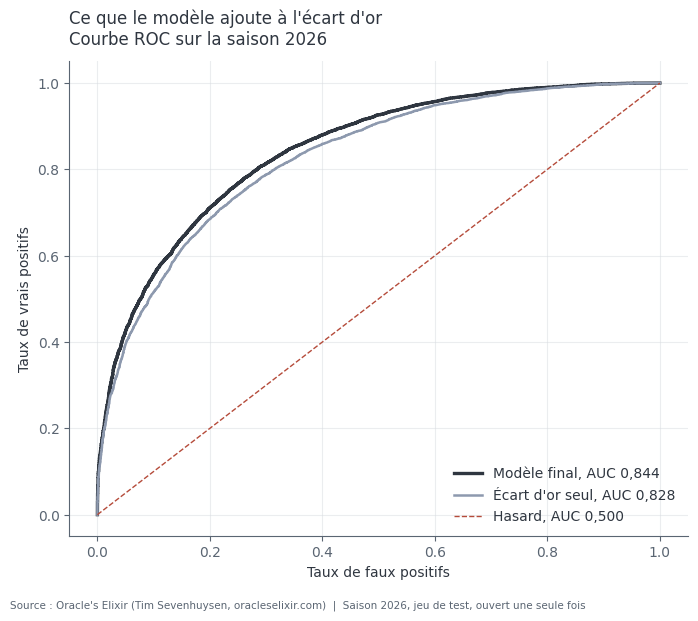

In [17]:
# Figure 1 : courbe ROC sur le test, a cote de l'ecart d'or tout seul.
auc_or_test = roc_auc_score(y_test, X_test["golddiffat15"])
fpr, tpr, _ = roc_curve(y_test, proba_test)
fpr_or, tpr_or, _ = roc_curve(y_test, X_test["golddiffat15"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=PALETTE["primary"], linewidth=2.4,
        label=f"Modèle final, AUC {nb(auc_test, 3)}")
ax.plot(fpr_or, tpr_or, color=PALETTE["accent"], linewidth=1.8,
        label=f"Écart d'or seul, AUC {nb(auc_or_test, 3)}")
ax.plot([0, 1], [0, 1], color=PALETTE["highlight"], linestyle="--", linewidth=1,
        label="Hasard, AUC 0,500")
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Ce que le modèle ajoute à l'écart d'or\n"
             "Courbe ROC sur la saison 2026", fontsize=12, pad=12, loc="left")
ax.legend(frameon=False, loc="lower right")
ax.grid(True, alpha=0.5)
fig.tight_layout()
viz.signer(fig, periode="Saison 2026, jeu de test, ouvert une seule fois")
viz.enregistrer(fig, "07_courbe_roc.png")
plt.show()

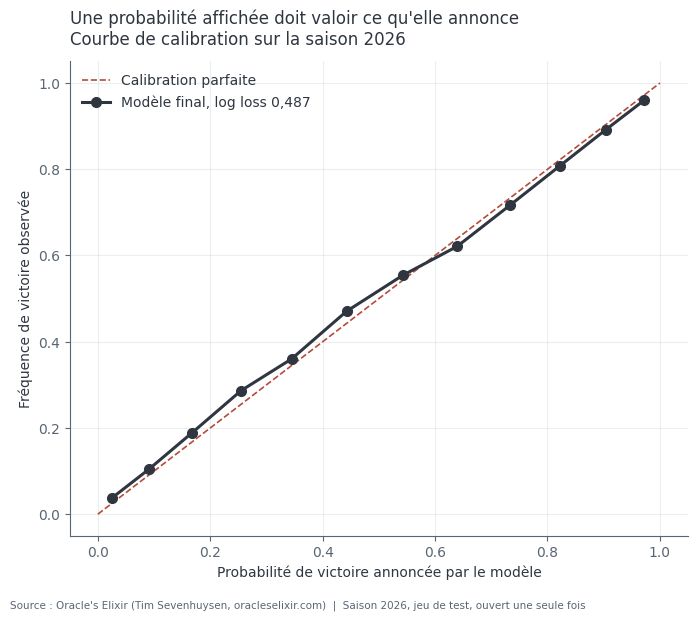

In [18]:
# Figure 2 : calibration. C'est elle qui justifie d'avoir choisi la log loss des le
# cadrage.
fraction, moyenne = calibration_curve(y_test, proba_test, n_bins=12, strategy="quantile")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color=PALETTE["highlight"], linewidth=1.2,
        label="Calibration parfaite")
ax.plot(moyenne, fraction, marker="o", markersize=7, color=PALETTE["primary"],
        linewidth=2.2, label=f"Modèle final, log loss {nb(final.loc[3, 'log_loss'], 3)}")
ax.set_xlabel("Probabilité de victoire annoncée par le modèle")
ax.set_ylabel("Fréquence de victoire observée")
ax.set_title("Une probabilité affichée doit valoir ce qu'elle annonce\n"
             "Courbe de calibration sur la saison 2026", fontsize=12, pad=12, loc="left")
ax.legend(frameon=False, loc="upper left")
ax.grid(True, alpha=0.5)
fig.tight_layout()
viz.signer(fig, periode="Saison 2026, jeu de test, ouvert une seule fois")
viz.enregistrer(fig, "07_calibration.png")
plt.show()

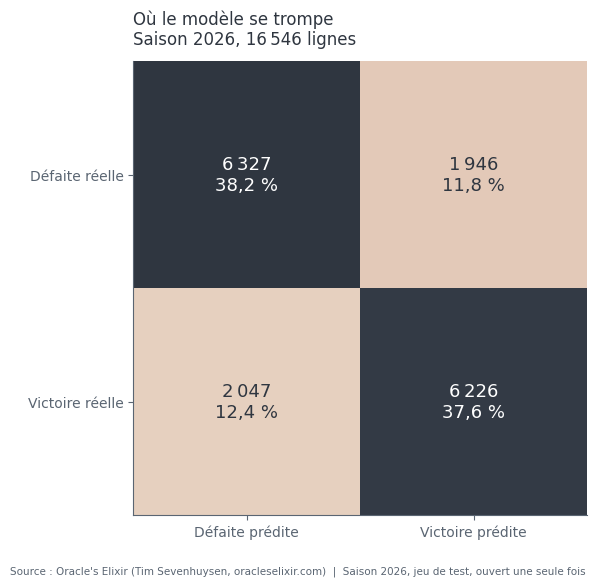

In [19]:
# Figure 3 : matrice de confusion.
fig, ax = plt.subplots(figsize=(6.4, 5.6))
image = ax.imshow(matrice, cmap=viz.CMAP_ARDOISE, vmin=0, vmax=matrice.max())

etiquettes = ["Défaite", "Victoire"]
ax.set_xticks([0, 1])
ax.set_xticklabels([f"{e} prédite" for e in etiquettes])
ax.set_yticks([0, 1])
ax.set_yticklabels([f"{e} réelle" for e in etiquettes])

for i in range(2):
    for j in range(2):
        part = 100 * matrice[i, j] / matrice.sum()
        ax.text(j, i, f"{fr(matrice[i, j])}\n{nb(part, 1)} %", ha="center", va="center",
                fontsize=13,
                color="white" if matrice[i, j] > matrice.max() * 0.55 else PALETTE["primary"])

ax.set_title("Où le modèle se trompe\n"
             f"Saison 2026, {fr(len(y_test))} lignes", fontsize=12, pad=12, loc="left")
fig.tight_layout()
viz.signer(fig, periode="Saison 2026, jeu de test, ouvert une seule fois", y=-0.02)
viz.enregistrer(fig, "07_matrice_confusion.png")
plt.show()

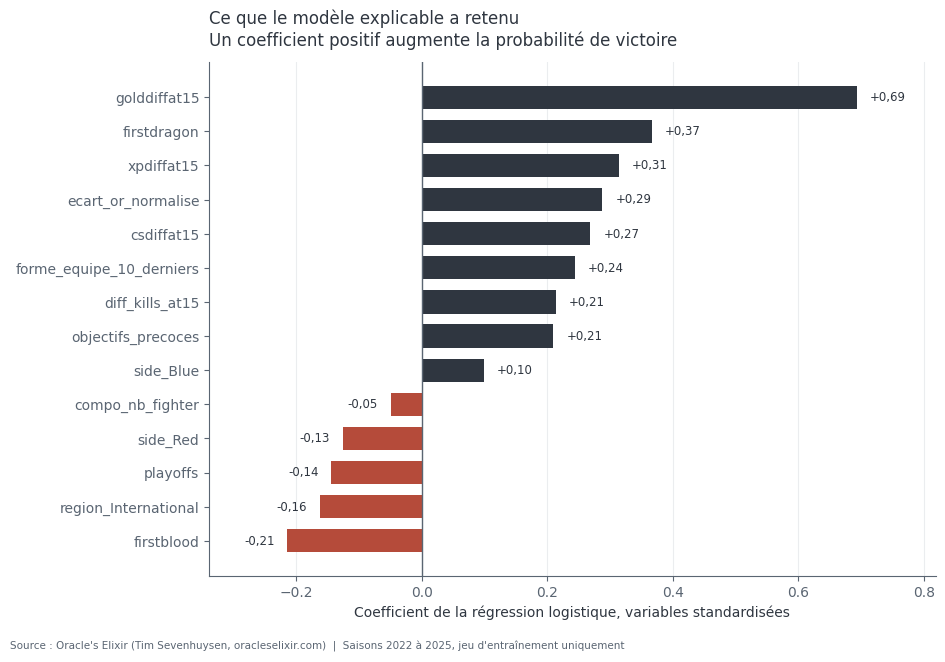

In [20]:
# Figure 4 : les coefficients signes de la regression logistique.
top_coef = coefficients.head(14).sort_values()
noms_lisibles = [n.split("__", 1)[1] for n in top_coef.index]
couleurs = [PALETTE["primary"] if v > 0 else PALETTE["highlight"] for v in top_coef]

fig, ax = plt.subplots(figsize=(9.5, 6.4))
ax.barh(noms_lisibles, top_coef.values, color=couleurs, height=0.68)
ax.axvline(0, color=PALETTE["secondary"], linewidth=1)
marge = 0.03 * max(abs(top_coef.min()), abs(top_coef.max()))
for y_pos, valeur in enumerate(top_coef.values):
    ax.text(valeur + (marge if valeur > 0 else -marge), y_pos,
            nb(valeur, 2, signe=True), va="center",
            ha="left" if valeur > 0 else "right", fontsize=8.5, color=PALETTE["primary"])
ax.set_xlabel("Coefficient de la régression logistique, variables standardisées")
ax.set_title("Ce que le modèle explicable a retenu\n"
             "Un coefficient positif augmente la probabilité de victoire",
             fontsize=12, pad=12, loc="left")
# On laisse de la marge des deux cotes, sinon l'etiquette du coefficient le plus negatif
# mord sur le nom de la variable.
ax.set_xlim(top_coef.min() - 6 * marge, top_coef.max() + 6 * marge)
ax.grid(True, axis="x", alpha=0.5)
fig.tight_layout()
viz.signer(fig)
viz.enregistrer(fig, "07_coefficients_logistique.png")
plt.show()

## 13. Biais et limites, lien avec le bloc 7

Le guide demande si le modèle présente un risque de biais selon un attribut sensible. Ici
l'attribut pertinent n'est pas une personne mais une **région** et un **niveau de ligue** : un
modèle qui prédirait bien l'Europe et mal l'Asie-Pacifique produirait des probabilités d'inégale
qualité selon la provenance de la partie, ce qui se verrait à l'écran.

In [21]:
diagnostic_test = donnees.loc[~est_train, ["region", "tier_ligue"]].copy()
diagnostic_test["vrai"] = y_test.to_numpy()
diagnostic_test["proba"] = proba_test
diagnostic_test["correct"] = (pred_test == y_test.to_numpy()).astype(int)


def performance_par(colonne, effectif_minimum=300):
    lignes = []
    for valeur, groupe in diagnostic_test.groupby(colonne):
        if len(groupe) < effectif_minimum or groupe["vrai"].nunique() < 2:
            continue
        lignes.append({
            colonne: valeur,
            "lignes": len(groupe),
            "accuracy": groupe["correct"].mean(),
            "roc_auc": roc_auc_score(groupe["vrai"], groupe["proba"]),
            "log_loss": log_loss(groupe["vrai"], groupe["proba"]),
        })
    return pd.DataFrame(lignes).sort_values("roc_auc", ascending=False)


par_region = performance_par("region")
par_tier = performance_par("tier_ligue")

print("Performance par region, groupes de plus de 300 lignes")
print(par_region.round(4).to_string(index=False))
print()
print("Performance par niveau de ligue")
print(par_tier.round(4).to_string(index=False))
print()
print(f"Ecart d'AUC entre la meilleure et la moins bonne region : "
      f"{par_region['roc_auc'].max() - par_region['roc_auc'].min():.4f}")

Performance par region, groupes de plus de 300 lignes
        region  lignes  accuracy  roc_auc  log_loss
Asie-Pacifique    1816    0.7819   0.8771    0.4351
       Turquie     408    0.7843   0.8757    0.4406
        Europe    6728    0.7626   0.8479    0.4826
         Coree    2486    0.7574   0.8377    0.4981
  Moyen-Orient     660    0.7212   0.8338    0.4922
     Ameriques    2700    0.7530   0.8336    0.5024
         Chine    1052    0.7367   0.8139    0.5335
 International     696    0.7399   0.8116    0.5276

Performance par niveau de ligue
 tier_ligue  lignes  accuracy  roc_auc  log_loss
          2    8134    0.7729   0.8621    0.4598
          3    3944    0.7632   0.8432    0.4915
          1    4468    0.7287   0.8079    0.5341

Ecart d'AUC entre la meilleure et la moins bonne region : 0.0655


In [22]:
# Derive de composition entre train et test, uniquement sur la region. Regarder la
# distribution des features du test, ce n'est pas regarder sa cible : aucune decision de
# modelisation n'en depend, le modele est deja fige.
part_train = donnees.loc[est_train, "region"].value_counts(normalize=True)
part_test = donnees.loc[~est_train, "region"].value_counts(normalize=True)

derive = pd.DataFrame({"part_train_pct": 100 * part_train,
                       "part_test_pct": 100 * part_test}).fillna(0)
derive["ecart_pts"] = derive["part_test_pct"] - derive["part_train_pct"]
print("Composition regionale, entrainement contre test")
print(derive.sort_values("ecart_pts", key=abs, ascending=False).round(2).to_string())

Composition regionale, entrainement contre test
                part_train_pct  part_test_pct  ecart_pts
region                                                  
Ameriques                25.01          16.32      -8.69
Chine                     0.20           6.36       6.16
Moyen-Orient              1.62           3.99       2.36
International             2.19           4.21       2.02
Asie-Pacifique           12.59          10.98      -1.62
Coree                    14.01          15.02       1.02
Europe                   41.35          40.66      -0.69
Turquie                   2.99           2.47      -0.52
CEI                       0.04           0.00      -0.04


### Ce que le diagnostic de biais révèle

**Le modèle est le moins performant sur le tier 1**, 0,808 d'AUC contre 0,862 pour le tier 2.
C'est contre-intuitif et pourtant cohérent avec la phase 5 : elle avait mesuré que le tier 1 est
marginalement le **moins déterministe**, avec un taux de remontée de 19,9 % contre 18,5 % en
tier 2. Les meilleures équipes renversent un peu plus souvent une partie mal engagée, donc l'état
de jeu à la 15e minute y prédit un peu moins bien. Le modèle retrouve, sans qu'on le lui demande,
un résultat établi deux phases plus tôt par une méthode entièrement différente.

**La Chine est le cas à signaler.** Elle obtient la plus mauvaise AUC régionale, 0,814, et le
tableau de dérive en donne la raison : elle pèse une part négligeable de l'entraînement et une
part bien plus importante du test. La règle de complétude de la phase 3, qui exige un snapshot
complet à 15 minutes sur les deux lignes d'une partie, avait écarté presque toute la LPL des
saisons 2022 à 2025 ; Oracle's Elixir renseigne ces colonnes en 2026. Le modèle prédit donc une
région qu'il n'a pratiquement jamais vue à l'entraînement.

Ce n'est pas un défaut du modèle, c'est une limite du périmètre, et elle doit être énoncée telle
quelle. Un déploiement réel exigerait de réentraîner dès que la LPL est disponible en volume.

**L'écart global de 0,066 d'AUC entre régions reste modéré** pour un modèle qui n'a jamais vu la
variable `league`. Il ne justifie pas de mesure correctrice, mais il justifie d'afficher un
intervalle de confiance différent selon la région si la probabilité devait être diffusée à
l'écran.

## 14. Export de la pipeline et démonstration

La pipeline **entière** est sauvegardée, preprocessing compris, comme l'exige le guide. Exporter
le seul estimateur obligerait à rejouer l'imputation, la standardisation et l'encodage à la main,
et la moindre différence fausserait les résultats en silence.

In [23]:
config.MODELS.mkdir(parents=True, exist_ok=True)
chemin_modele = config.MODELS / "pipeline_final.joblib"
joblib.dump(meilleur_modele, chemin_modele)

# On recharge et on verifie que l'objet donne exactement les memes predictions.
recharge = joblib.load(chemin_modele)
proba_recharge = recharge.predict_proba(X_test)[:, 1]

print(f"Pipeline exportee : {chemin_modele.name} "
      f"({chemin_modele.stat().st_size / 1e6:.2f} Mo)")
print(f"Etapes : {[nom for nom, _ in recharge.steps]}")
print(f"Predictions identiques apres rechargement : "
      f"{bool(np.allclose(proba_test, proba_recharge))}")

Pipeline exportee : pipeline_final.joblib (0.01 Mo)
Etapes : ['preprocessing', 'modele']
Predictions identiques apres rechargement : True


In [24]:
# Demo sur des lignes brutes, comme demande dans le guide. On tire au hasard (graine
# fixe) plutot que de prendre les premieres lignes : elles viennent toutes de la meme
# journee et de la meme ligue, ca n'illustre rien.
demo = X_test.sample(6, random_state=RANDOM_STATE)
index_demo = demo.index

apercu = donnees.loc[index_demo, ["date", "league", "teamname", "side",
                                  "golddiffat15"]].copy()
apercu["proba_victoire"] = recharge.predict_proba(demo)[:, 1].round(3)
apercu["prediction"] = np.where(recharge.predict(demo) == 1, "Victoire", "Defaite")
apercu["resultat_reel"] = np.where(y.loc[index_demo] == 1, "Victoire", "Defaite")
apercu["correct"] = np.where(apercu["prediction"] == apercu["resultat_reel"], "oui", "non")

print("Prediction sur six parties de 2026, a partir des donnees brutes")
print(apercu.to_string(index=False))
print()
justes = int((apercu["correct"] == "oui").sum())
print(f"{justes} sur 6 correctes sur cet echantillon. Sur les {fr(len(y_test))} lignes de "
      f"2026, le modele est juste {100 * accuracy_test:.1f} % du temps : un echantillon de "
      f"six lignes ne mesure rien, il illustre seulement le format de sortie.")

Prediction sur six parties de 2026, a partir des donnees brutes
               date league             teamname side  golddiffat15  proba_victoire prediction resultat_reel correct
2026-05-14 16:24:40    HLL                 GOAL Blue         528.0           0.684   Victoire      Victoire     oui
2026-05-13 12:47:29    VCS  MVK Esports Academy  Red       -3703.0           0.109    Defaite       Defaite     oui
2026-05-01 23:23:32   NACL           Blue Otter  Red       -1091.0           0.320    Defaite       Defaite     oui
2026-09-02 11:38:32    LCK  Hanwha Life Esports  Red        -973.0           0.482    Defaite      Victoire     non
2026-03-07 11:44:11    LJL                NOVEX Blue        5877.0           0.977   Victoire      Victoire     oui
2026-05-02 05:51:25    LAS HANJIN BRION Academy Blue          53.0           0.568   Victoire      Victoire     oui

5 sur 6 correctes sur cet echantillon. Sur les 16 546 lignes de 2026, le modele est juste 75.9 % du temps : un echantillon 

In [25]:
# La demo fait ressortir une incoherence de structure : les deux lignes d'une meme
# partie sont predites chacune de leur cote, donc leurs probas ne font pas forcement 1 a
# elles deux.
paires = pd.DataFrame({
    "gameid": donnees.loc[~est_train, "gameid"].to_numpy(),
    "proba": proba_test,
})
somme = paires.groupby("gameid")["proba"].sum()

print("Somme des deux probabilites d'une meme partie, qui devrait valoir 1,000")
print(f"  mediane        : {somme.median():.3f}")
print(f"  1er et 9e decile : {somme.quantile(0.1):.3f} a {somme.quantile(0.9):.3f}")
print(f"  ecart maximal a 1 : {(somme - 1).abs().max():.3f}")
print()
print(f"Parties ou les deux equipes sont donnees gagnantes : "
      f"{int(((paires.groupby('gameid')['proba'].min()) > 0.5).sum())}")

Somme des deux probabilites d'une meme partie, qui devrait valoir 1,000
  mediane        : 0.995
  1er et 9e decile : 0.904 a 1.068
  ecart maximal a 1 : 0.315

Parties ou les deux equipes sont donnees gagnantes : 220


### Ce que la dernière cellule met au jour

Le modèle prédit **une ligne équipe à la fois**, sans savoir que deux lignes forment une partie.
Rien ne lui impose donc que les deux probabilités d'une même partie somment à 1, et elles ne le
font qu'approximativement.

En pratique la contrainte est presque respectée, parce que les features sont construites en
miroir : l'écart d'or d'une équipe est l'opposé de celui de son adversaire. Mais « presque » n'est
pas « exactement », et pour un affichage à l'écran c'est visible : annoncer 59 % d'un côté et 26 %
de l'autre laisse 15 % dans la nature.

**Correction pour une mise en production**, hors du périmètre de ce projet : normaliser les deux
probabilités d'une partie pour qu'elles somment à 1, ou reformuler le problème au niveau de la
partie plutôt que de l'équipe, avec une seule ligne par partie et des features en différence. La
seconde option est plus propre et diviserait le jeu par deux ; elle a été écartée en phase 0 parce
que la structure à deux lignes d'Oracle's Elixir garantit l'équilibre 50/50 de la cible.

## 15. Export du rapport de modélisation

In [26]:
def tableau_markdown(df):
    entete = "| " + " | ".join(str(c) for c in df.columns) + " |"
    separateur = "|" + "|".join(["---"] * len(df.columns)) + "|"
    corps = ["| " + " | ".join(str(v) for v in ligne) + " |"
             for ligne in df.itertuples(index=False)]
    return "\n".join([entete, separateur] + corps)


nom_modele = meilleur_modele.named_steps["modele"].__class__.__name__
gain_pts = 100 * (final.loc[3, "accuracy"] - final.loc[2, "accuracy"])
coef_doc = (coefficients.head(10).round(4).rename("coefficient")
            .rename_axis("feature").reset_index())
verdict_phase6 = "confirmee" if rang_dragon < rang_sang else "infirmee"

rapport = f"""# Rapport de modelisation, phase 7

Document genere par `notebooks/07_modelisation.ipynb`, a ne pas editer a la main.

Donnees fournies par Oracle's Elixir (Tim Sevenhuysen, oracleselixir.com).

## Cadrage

| Element | Valeur |
|---|---|
| Question predictive | Quelle equipe gagne, sachant l'etat de jeu a la 15e minute |
| Cible | `result`, classification binaire, {100 * donnees[CIBLE].mean():.1f} % de positifs |
| Features | {len(FEATURES)} colonnes, toutes connues a la 15e minute |
| Metrique principale | ROC AUC |
| Metriques secondaires | accuracy pour la communication, log loss pour la calibration |
| Entrainement | {fr(len(X_train))} lignes, 2022 a 2025 |
| Test | {fr(len(X_test))} lignes, saison 2026, ouvert une seule fois |
| Graine aleatoire | {RANDOM_STATE}, fixee partout |

## Ecarts assumes au squelette du formateur

| Squelette | Ce projet | Justification |
|---|---|---|
| `train_test_split` aleatoire | Split chronologique sur la date | Le modele sert a predire des parties futures, un split aleatoire entrainerait sur des parties posterieures a celles qu'il evalue |
| `cv=5`, donc `KFold` | `TimeSeriesSplit(n_splits=5)` | Un `KFold` remelange l'ordre temporel dans le train et reproduit a petite echelle le probleme que le split chronologique corrige |
| Jeu de validation separe | Les cinq plis de `TimeSeriesSplit` | Chaque pli valide sur des parties posterieures a son entrainement, cinq fois au lieu d'une |

## Baselines, mesurees avant tout modele

{tableau_markdown(baselines.round(4))}

La baseline economique atteint {100 * BASELINE_A_BATTRE:.2f} % sur l'entrainement. C'est la
reference qui compte : une regle d'une ligne capture deja l'essentiel du signal, ce que la
phase 6 avait annonce en montrant que 28 % des lignes presentent plus de 3 000 or d'ecart.

## Comparaison des modeles, validation croisee temporelle

{tableau_markdown(par_famille[["famille", "hyperparametres", "mean_test_roc_auc", "mean_test_accuracy", "log_loss"]].round(4))}

Modele retenu : **{nom_modele}**, AUC de {grille.best_score_:.4f} en validation croisee.
Ecart d'AUC entre la meilleure et la moins bonne famille : {ecart_familles:.4f}.

## Diagnostic de surapprentissage

Taille d'un pli de validation : {fr(taille_pli)} lignes.

{tableau_markdown(diagnostic[["famille", "mean_train_roc_auc", "mean_test_roc_auc", "ecart_auc", "lignes_concernees"]].round(4))}

## Verdict final, saison 2026

{tableau_markdown(final.round(4))}

Gain du modele sur la baseline economique : {gain_pts:+.2f} points d'accuracy, soit
{fr(abs(gain_pts / 100) * len(y_test))} lignes mieux classees sur {fr(len(y_test))}.

Ecart entrainement / test : {auc_train_final - auc_test:+.4f} d'AUC et
{acc_train_final - accuracy_test:+.4f} d'accuracy, soit
{fr(abs(acc_train_final - accuracy_test) * len(y_test))} lignes du jeu de test.

## Comparaison des protocoles de split

{tableau_markdown(protocoles.round(4))}

Le split aleatoire affiche {100 * (auc_alea - auc_test):+.2f} points d'AUC par rapport au split
chronologique, soit l'inverse de ce que la phase 0 anticipait.

L'explication n'est pas que le split aleatoire serait vertueux, mais que les deux protocoles
n'evaluent pas sur la meme population. Le test chronologique ne contient que 2026, une saison
homogene ; le test aleatoire tire ses lignes des cinq saisons, y compris les plus anciennes et
les plus heterogenes, et il est donc mecaniquement plus difficile. L'effet de composition
l'emporte ici sur l'effet d'optimisme.

Le choix du split chronologique ne se justifie donc pas par le score, il se justifie par la
condition d'usage : le modele servira a predire des parties futures, et c'est cela qu'il faut
simuler, que le score y gagne ou y perde.

## Interpretation

Coefficients de la regression logistique, variables standardisees, dix premiers en valeur
absolue :

{tableau_markdown(coef_doc)}

Prediction laissee par la phase 6, `firstdragon` devant `firstblood` : **{verdict_phase6}**.
`firstdragon` au rang {rang_dragon}, `firstblood` au rang {rang_sang}.

## Biais, lien avec le bloc 7

Performance par region, groupes de plus de 300 lignes :

{tableau_markdown(par_region.round(4))}

Ecart d'AUC entre la meilleure et la moins bonne region :
{par_region['roc_auc'].max() - par_region['roc_auc'].min():.4f}.

Performance par niveau de ligue :

{tableau_markdown(par_tier.round(4))}

Deux constats a signaler.

Le modele est le **moins performant sur le tier 1**, ce qui est coherent avec la phase 5 : elle
avait mesure que le tier 1 est marginalement le moins deterministe, avec un taux de remontee de
19,9 % contre 18,5 % en tier 2. Les meilleures equipes renversent un peu plus souvent une partie
mal engagee, donc l'etat de jeu a la 15e minute y predit un peu moins bien. Le modele retrouve
sans qu'on le lui demande un resultat etabli deux phases plus tot par une methode differente.

La **Chine** obtient la plus mauvaise AUC regionale. La regle de completude de la phase 3 avait
ecarte presque toute la LPL des saisons 2022 a 2025, alors qu'Oracle's Elixir renseigne les
colonnes a 15 minutes en 2026 : le modele predit une region qu'il n'a pratiquement jamais vue a
l'entrainement. C'est une limite du perimetre et non un defaut du modele, et un deploiement reel
exigerait de reentrainer des que la LPL est disponible en volume.

## Limite structurelle du cadrage

Le modele predit une ligne equipe a la fois et ignore que deux lignes forment une partie. Les
deux probabilites d'une meme partie ne somment donc a 1 qu'approximativement, ce qui se verrait
sur un affichage temps reel. Une mise en production normaliserait les deux probabilites, ou
reformulerait le probleme au niveau de la partie avec des features en difference.

## Livrables

- `models/pipeline_final.joblib`, pipeline complete, preprocessing inclus
- `figures/07_courbe_roc.png`
- `figures/07_calibration.png`
- `figures/07_matrice_confusion.png`
- `figures/07_coefficients_logistique.png`
"""

chemin_rapport = config.DOCS / "rapport_modelisation.md"
chemin_rapport.write_text(rapport, encoding="utf-8")
print(f"Rapport ecrit : {chemin_rapport}")
print(f"{fr(len(rapport))} caracteres")

Rapport ecrit : E:\LWP(LoLWinPrediciton)\lol-win-prediction\docs\rapport_modelisation.md
7 334 caracteres


## 16. Réflexion

Les cinq questions de la section 9 du guide.

**1. Le gain est-il réel ?** Il est réel mais modeste, et il faut le présenter ainsi. Sur 2026, la
baseline « le plus riche à 15 gagne » atteint 74,5 % et le modèle 75,9 % : **1,4 point d'accuracy,
soit 229 lignes mieux classées sur 16 546**. Défendre ce projet sur ce chiffre serait faible.

Ce qu'il faut défendre est ailleurs. La baseline ne produit pas de probabilité, seulement un
verdict binaire : elle est incapable de distinguer une partie serrée d'une partie pliée. Le modèle
atteint 0,844 d'AUC et une log loss de 0,487, c'est-à-dire qu'il **classe** les parties et
**calibre** ses annonces. Or le livrable métier défini au cadrage est une probabilité affichée à
l'écran pendant une diffusion. Le modèle apporte donc quelque chose que la baseline ne peut pas
donner du tout, et l'accuracy n'est pas la métrique qui le montre. C'est exactement pourquoi la
log loss avait été inscrite au cadrage comme métrique secondaire.

**2. Le modèle simple faisait-il presque aussi bien ?** Mieux que ça : **il a gagné.** La
régression logistique arrive première en AUC de validation croisée, devant la forêt aléatoire et
le gradient boosting, et les trois familles tiennent en 0,003 d'AUC. Elle est aussi la mieux
calibrée, log loss de 0,496 contre 0,500 et 0,501, et de loin la moins sujette au
surapprentissage : 38 lignes d'écart entre entraînement et validation, contre 584 pour la forêt.

C'est le meilleur résultat possible pour ce projet. Le modèle retenu est celui dont on peut lire
les coefficients un par un et les confronter à l'EDA, et il n'a rien coûté en performance. Le
guide prévenait qu'un modèle simple aussi bon qu'un ensembliste est « un excellent résultat à
commenter » : c'est le cas ici, et la raison est que la relation entre l'écart d'or et la victoire
est quasi linéaire dans la zone utile, comme la courbe de conversion de la phase 6 le montrait
déjà.

**3. Accepterais-je que ce modèle décide à ma place ?** Pour afficher une probabilité pendant une
diffusion, oui, sous réserve de la courbe de calibration. Pour arbitrer un recrutement ou une
décision de coaching, non : il prédit une issue, il n'explique pas une causalité, et la phase 5 a
montré que ses variables les plus fortes sont des mesures de domination déjà acquise.

**4. Quelle colonne aurait pu me faire tomber dans le piège ?** `firsttower`, écartée en phase 3
contre le cadrage initial qui la classait connue à la 15e minute. Elle est attribuée dans 100 %
des parties, là où les trois autres objectifs laissent des parties sans titulaire, et elle corrèle
à 0,391 contre 0,18 à 0,25 pour les autres. En jeu professionnel la première tourelle tombe
souvent après la 15e minute. Plus subtil encore, `ecart_or_normalise` a bien failli fuiter par sa
médiane de patch, calculée sur tout le patch au lieu du passé seul.

**5. Modèle ou données ?** Les données, sans hésitation. Trois familles de modèles se tiennent en
quelques millièmes d'AUC, ce qui est le signe que le plafond vient de l'information disponible et
non de l'algorithme. Ce qui ferait progresser ce projet, c'est l'ordre de la draft, un classement
de type Elo par équipe, ou un état de jeu à la 15e minute plus fin que huit agrégats. Changer de
modèle ne donnerait rien.

## Ce que la phase 8 reprendra

Le dataset final, la pipeline exportée et les rapports générés par les notebooks 02 à 07.